<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Geospatial%20Analysis%20of%20Global%20F1%20Tracks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geospatial Analysis of Global F1 Tracks

## Geospatial Analysis of Global F1 Tracks: Key Insights
This analysis delved into a dataset of Formula 1 circuits, focusing on their geographical properties such as latitude, longitude, and altitude. The primary goal was to uncover patterns, classify tracks, and understand how geographical factors might influence F1 operations, particularly in terms of aerodynamics, climate, and logistics.

Data Overview & Preparation: The dataset contained 77 unique F1 circuits with details like circuitId, name, location, country, lat (latitude), lng (longitude), and alt (altitude). Initial data cleaning involved converting the alt column to numeric values and imputing any missing data with the mean altitude, ensuring data integrity for subsequent analyses.

Feature Engineering for Deeper Understanding: Several new features were engineered to provide more actionable insights:

Aerodynamic Profile: Tracks were categorized into 'Sea Level (High Downforce)', 'Standard Elevation', and 'High Altitude (Thin Air)' based on their altitude. This directly relates to how air density affects car performance and engine cooling.
Climate & Tire Degradation Risk: By calculating the absolute distance from the equator (Equator_Distance_Deg), tracks were classified into 'High Risk (Tropics)', 'Medium Risk (Sub-tropics)', and 'Low Risk (Temperate)' zones. This provides a proxy for understanding potential tire degradation due to heat and humidity.
Logistics Zones: Tracks were grouped into broader geographical regions like 'Europe Zone', 'Americas Zone', 'Asia-Pacific Zone', 'Middle East / Africa Zone', and 'Other' based on their latitude and longitude. This helps in strategic planning for transport and resource allocation.
Hemisphere: A simple classification of 'Northern' or 'Southern' Hemisphere was added, which can be crucial for understanding seasonal variations.
Key Statistical Insights:

Hemisphere vs. Altitude (T-Test): Our analysis showed no statistically significant difference in altitude between tracks in the Northern and Southern Hemispheres. This suggests that simply being in one hemisphere or the other doesn't dictate a track's elevation profile.
Logistics Zone vs. Altitude (ANOVA): Similar to the hemisphere test, the ANOVA test revealed no statistically significant differences in average altitudes across the defined Logistics Zones. This implies that, on average, the elevation profiles are relatively consistent across these broad regions.
Climate vs. Altitude (Pearson Correlation): There was no significant linear correlation found between a track's distance from the equator and its altitude. This disproves the initial hypothesis that tracks closer to the equator might be built at higher altitudes to escape heat.
Logistics Zone vs. Climate Risk (Chi-Square): A highly significant dependence was found between Logistics Zones and Climate & Tire Risk levels (p-value < 0.05). This is a crucial insight: certain logistics zones are strongly associated with specific tire degradation risks, which is vital for tire allocation and strategy.
Machine Learning for Track Profiling: K-Means clustering was applied to alt, lat, and lng to identify natural groupings of tracks based purely on their geographical characteristics. Four distinct 'Track Profiles' emerged, which could represent different types of racing environments. Visualizations of Latitude vs. Altitude for these profiles confirmed that these clusters represent meaningful differences in geographical characteristics, suggesting different operational considerations for each profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d thedrzee/geospatial-analysis-of-global-f1-tracks

# Unziping the downloaded file
!unzip geospatial-analysis-of-global-f1-tracks.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/thedrzee/geospatial-analysis-of-global-f1-tracks
License(s): CC0-1.0
  0% 0.00/3.67k [00:00<?, ?B/s]
100% 3.67k/3.67k [00:00<00:00, 13.2MB/s]
Archive:  geospatial-analysis-of-global-f1-tracks.zip
  inflating: circuits.csv            


# Data Inspection

In [4]:
df = pd.read_csv('circuits.csv')
df.head(11)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park
5,6,monaco,Circuit de Monaco,Monte-Carlo,Monaco,43.73470,7.42056,7,http://en.wikipedia.org/wiki/Circuit_de_Monaco
6,7,villeneuve,Circuit Gilles Villeneuve,Montreal,Canada,45.50000,-73.52280,13,http://en.wikipedia.org/wiki/Circuit_Gilles_Vi...
7,8,magny_cours,Circuit de Nevers Magny-Cours,Magny Cours,France,46.86420,3.16361,228,http://en.wikipedia.org/wiki/Circuit_de_Nevers...
8,9,silverstone,Silverstone Circuit,Silverstone,UK,52.07860,-1.01694,153,http://en.wikipedia.org/wiki/Silverstone_Circuit
9,10,hockenheimring,Hockenheimring,Hockenheim,Germany,49.32780,8.56583,103,http://en.wikipedia.org/wiki/Hockenheimring


In [5]:
df.tail(11)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
66,67,pedralbes,Circuit de Pedralbes,Barcelona,Spain,41.3903,2.11667,85,http://en.wikipedia.org/wiki/Pedralbes_Circuit
67,68,buddh,Buddh International Circuit,Uttar Pradesh,India,28.3487,77.53310,194,http://en.wikipedia.org/wiki/Buddh_Internation...
68,69,americas,Circuit of the Americas,Austin,USA,30.1328,-97.64110,161,http://en.wikipedia.org/wiki/Circuit_of_the_Am...
69,70,red_bull_ring,Red Bull Ring,Spielberg,Austria,47.2197,14.76470,678,http://en.wikipedia.org/wiki/Red_Bull_Ring
70,71,sochi,Sochi Autodrom,Sochi,Russia,43.4057,39.95780,2,http://en.wikipedia.org/wiki/Sochi_Autodrom
71,73,baku,Baku City Circuit,Baku,Azerbaijan,40.3725,49.85330,-7,http://en.wikipedia.org/wiki/Baku_City_Circuit
72,75,portimao,Autódromo Internacional do Algarve,Portimão,Portugal,37.2270,-8.62670,108,http://en.wikipedia.org/wiki/Algarve_Internati...
73,76,mugello,Autodromo Internazionale del Mugello,Mugello,Italy,43.9975,11.37190,255,http://en.wikipedia.org/wiki/Mugello_Circuit
74,77,jeddah,Jeddah Corniche Circuit,Jeddah,Saudi Arabia,21.6319,39.10440,15,http://en.wikipedia.org/wiki/Jeddah_Street_Cir...
75,78,losail,Losail International Circuit,Al Daayen,Qatar,25.4900,51.45420,12,http://en.wikipedia.org/wiki/Losail_Internatio...


In [6]:
df.shape

(77, 9)

In [7]:
df.columns

Index(['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng',
       'alt', 'url'],
      dtype='object')

In [8]:
df.dtypes

,0
circuitId,int64
circuitRef,object
name,object
location,object
country,object
lat,float64
lng,float64
alt,int64
url,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     object 
 2   name        77 non-null     object 
 3   location    77 non-null     object 
 4   country     77 non-null     object 
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
circuitId,77.0,NaN,NaN,NaN,39.883117,23.001701,1.0,20.0,40.0,59.0,80.0
circuitRef,77,77,albert_park,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,77,77,Albert Park Grand Prix Circuit,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,77,75,California,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,77,35,USA,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,77.0,NaN,NaN,NaN,33.442925,22.808866,-37.8497,32.7774,40.9517,46.9589,57.2653
lng,77.0,NaN,NaN,NaN,1.076683,65.516951,-118.189,-9.39417,3.93083,19.2486,144.968
alt,77.0,NaN,NaN,NaN,247.012987,362.738469,-7.0,18.0,129.0,332.0,2227.0
url,77,77,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
circuitId,0
circuitRef,0
name,0
location,0
country,0
lat,0
lng,0
alt,0
url,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

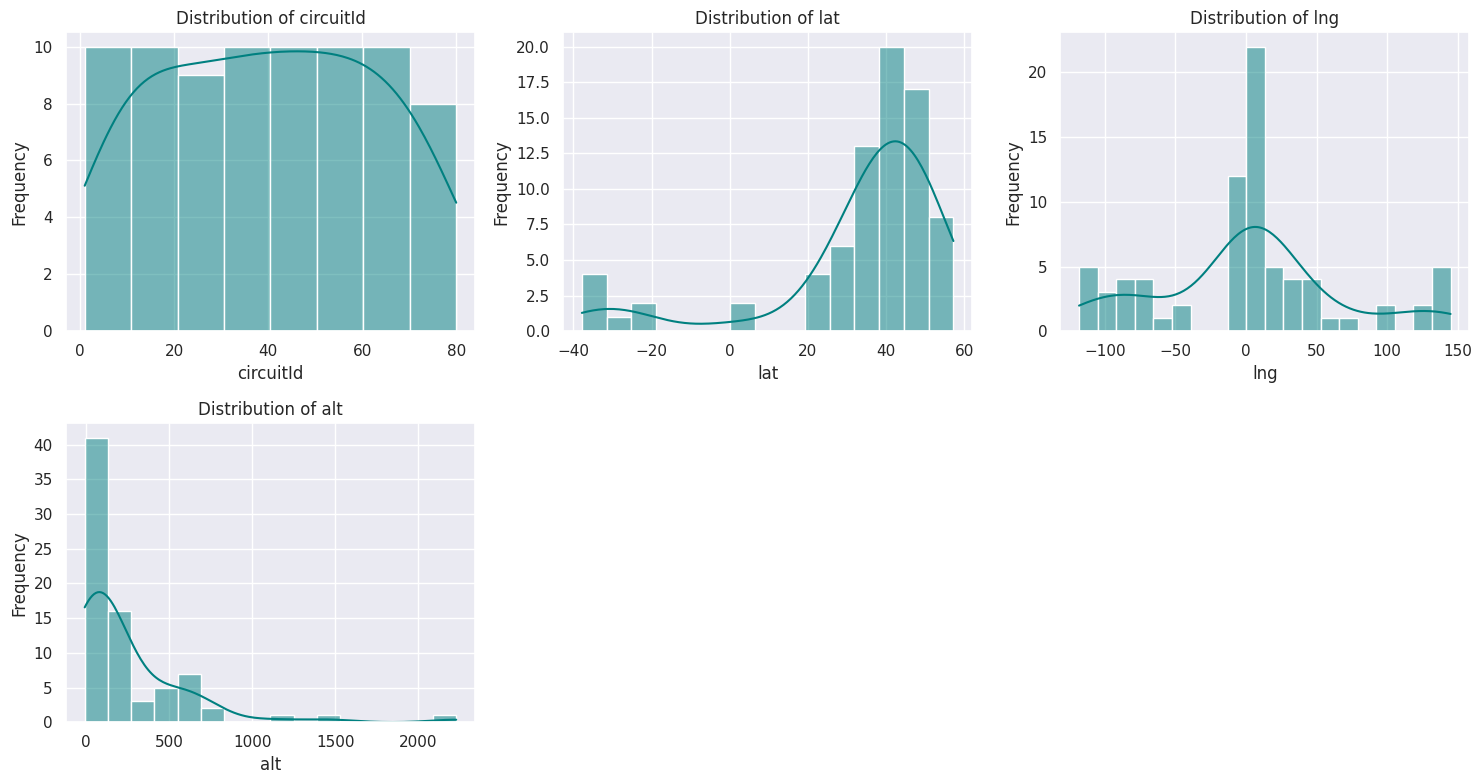

No categorical columns found (or all have high cardinality).


In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

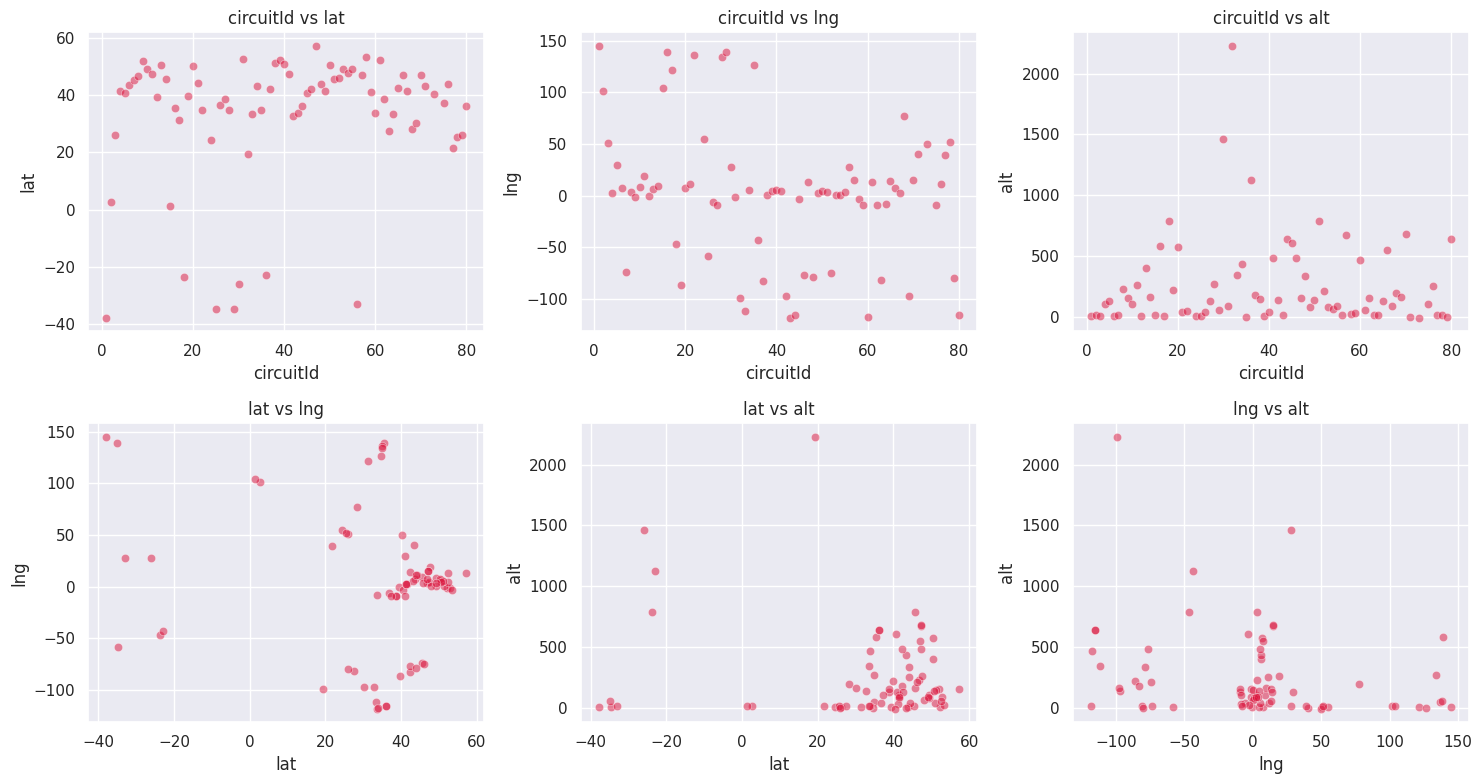

No categorical-numerical pairs found.


In [14]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

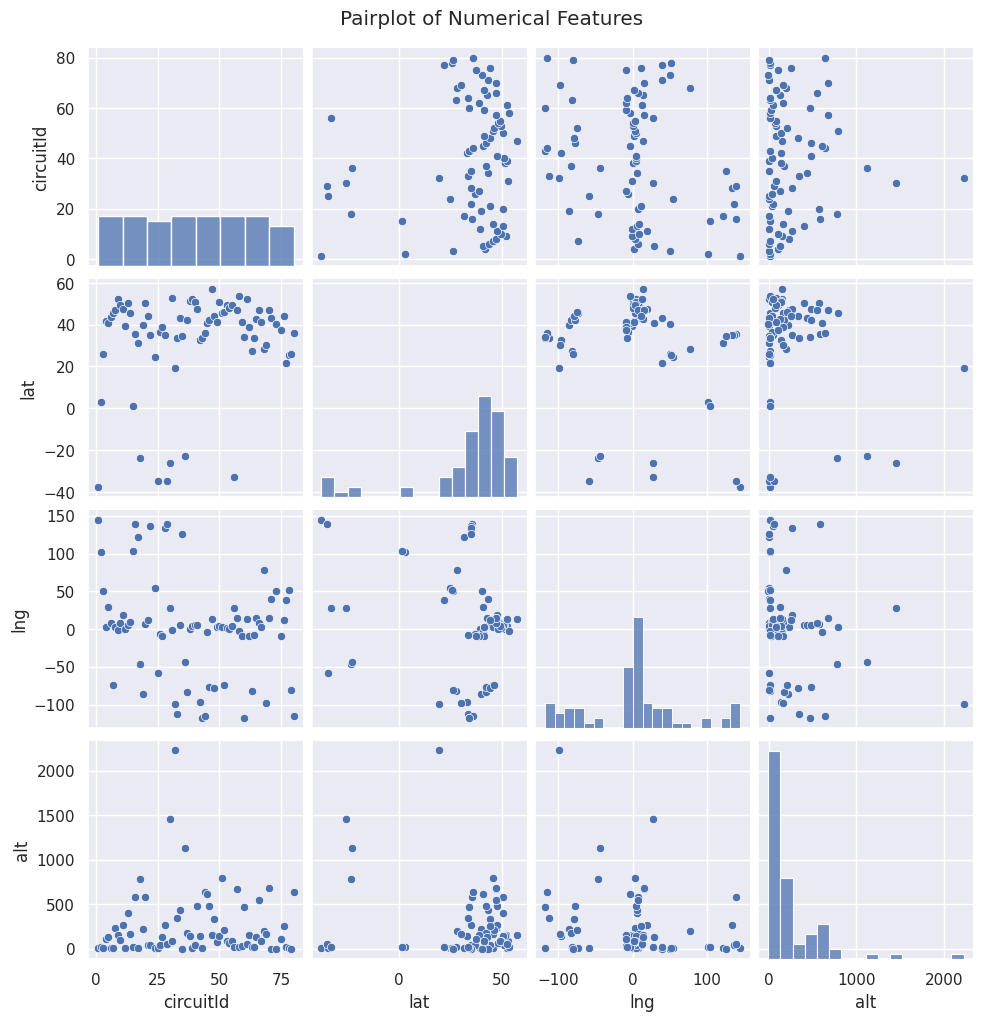

In [15]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

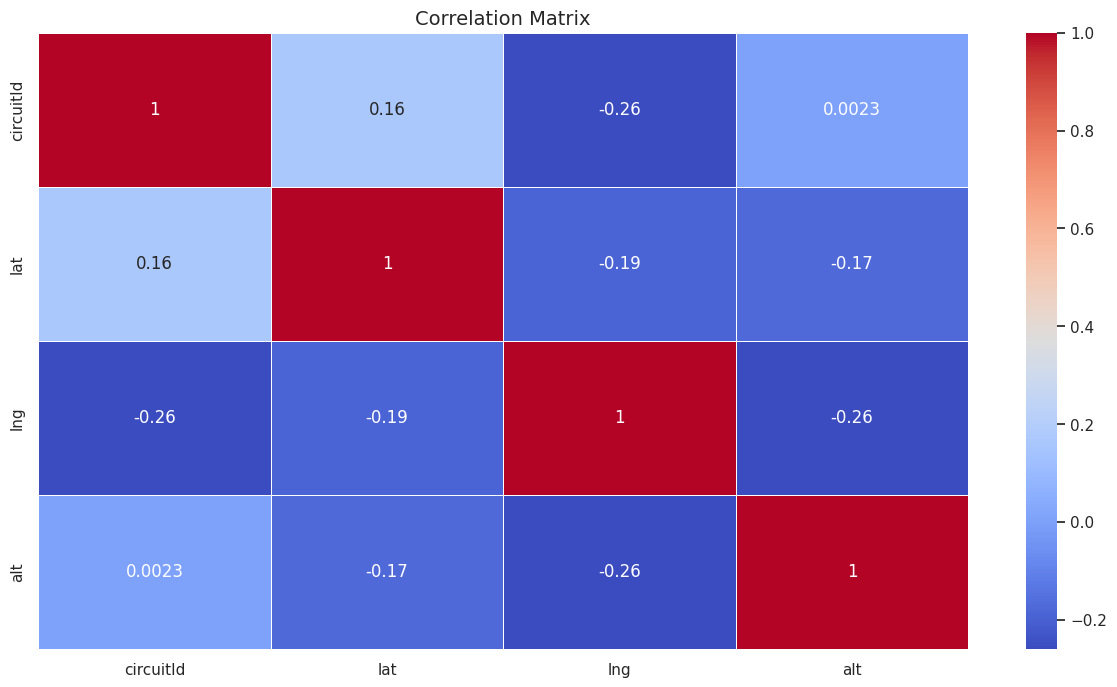

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. THE HEMISPHERE ELEVATION TEST (T-TEST) ---
T-Test P-Value: 2.9313e-01
❌ Insight: Hemisphere does not dictate track altitude. They are relatively similar.

--- 2. LOGISTICS ZONE VARIANCES (ANOVA) ---
ANOVA P-Value: 1.4470e-01
❌ Insight: The logistics zones share roughly the same average altitudes across the board.

--- 3. CLIMATE VS. ALTITUDE (PEARSON CORRELATION) ---
Pearson Correlation Coefficient: -0.1500
P-Value: 1.9286e-01
❌ Insight: There is no mathematical relationship between how close a track is to the equator and its altitude.


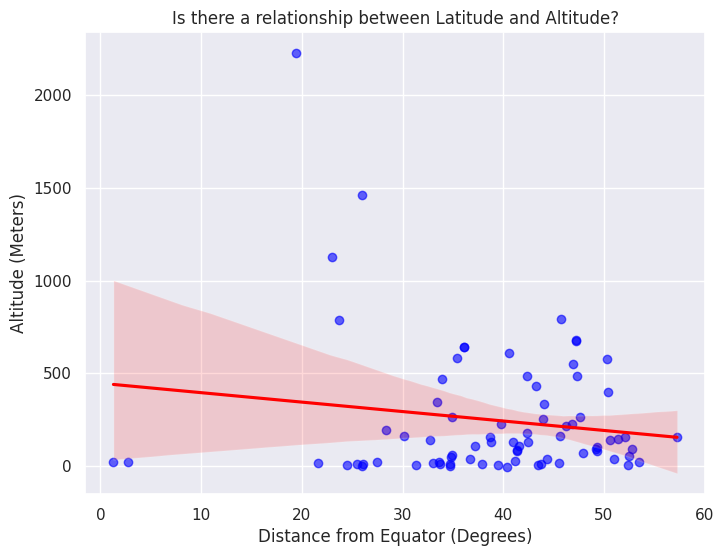


--- 4. ZONE & CLIMATE DEPENDENCE (CHI-SQUARE) ---
Chi-Square P-Value: 4.7898e-07
✅ Insight: Strong dependence found. Certain logistics zones guarantee specific climate risks for our tires.


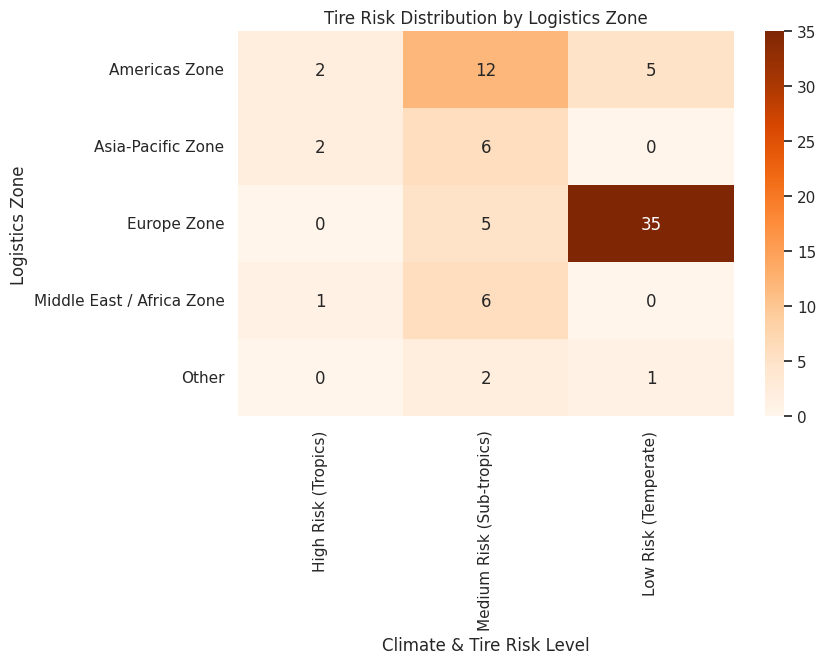

In [27]:
# ==========================================
# PHASE 6: STATISTICAL ANALYSIS
# ==========================================
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. THE HEMISPHERE ELEVATION TEST (T-TEST) ---")
# I want to know if tracks in the Northern Hemisphere are built at fundamentally
# different altitudes than tracks in the Southern Hemisphere.

# Splitting our data into two groups
north_tracks = df[df['Hemisphere'] == 'Northern']['alt'].dropna()
south_tracks = df[df['Hemisphere'] == 'Southern']['alt'].dropna()

# Running an Independent T-Test
t_stat, p_val_t = stats.ttest_ind(north_tracks, south_tracks, equal_var=False)

print(f"T-Test P-Value: {p_val_t:.4e}")
if p_val_t < 0.05:
    print("✅ Insight: We found a statistically significant difference in altitude between hemispheres.")
else:
    print("❌ Insight: Hemisphere does not dictate track altitude. They are relatively similar.")


print("\n--- 2. LOGISTICS ZONE VARIANCES (ANOVA) ---")
# Let's see if our Logistics Zones have completely different elevation profiles.
# This matters because shipping high-altitude engine parts to specific zones requires planning.

# Grouping altitude data by Logistics Zone
zones = df['Logistics_Zone'].unique()
zone_groups = [df[df['Logistics_Zone'] == zone]['alt'].dropna() for zone in zones]

# Running a One-Way ANOVA test for multiple groups
f_stat, p_val_anova = stats.f_oneway(*zone_groups)

print(f"ANOVA P-Value: {p_val_anova:.4e}")
if p_val_anova < 0.05:
    print("✅ Insight: Elevation is significantly different depending on the global zone we travel to.")

    # Let's visualize what we just proved mathematically
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Logistics_Zone', y='alt', data=df, palette='Set2')
    plt.title('Elevation Profiles Across Our Logistics Zones')
    plt.xticks(rotation=45)
    plt.ylabel('Altitude (Meters)')
    plt.show()
else:
    print("❌ Insight: The logistics zones share roughly the same average altitudes across the board.")


print("\n--- 3. CLIMATE VS. ALTITUDE (PEARSON CORRELATION) ---")
# I'm curious if tracks built closer to the equator (hotter climates) tend to be built higher up
# in the mountains to escape the extreme heat. Let's test the correlation.

# We need continuous numbers for this, so we drop any missing values
corr_data = df[['Equator_Distance_Deg', 'alt']].dropna()
corr_coef, p_val_corr = stats.pearsonr(corr_data['Equator_Distance_Deg'], corr_data['alt'])

print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_val_corr:.4e}")

if p_val_corr < 0.05:
    print("✅ Insight: We have a significant correlation!")
    if corr_coef < 0:
        print("   -> As we get closer to the equator, tracks tend to be built at HIGHER altitudes.")
    else:
        print("   -> As we move further from the equator, tracks tend to be built at HIGHER altitudes.")
else:
    print("❌ Insight: There is no mathematical relationship between how close a track is to the equator and its altitude.")

# Visualizing the relationship we just tested
plt.figure(figsize=(8, 6))
sns.regplot(x='Equator_Distance_Deg', y='alt', data=corr_data, scatter_kws={'alpha':0.6, 'color':'blue'}, line_kws={'color':'red'})
plt.title('Is there a relationship between Latitude and Altitude?')
plt.xlabel('Distance from Equator (Degrees)')
plt.ylabel('Altitude (Meters)')
plt.show()


print("\n--- 4. ZONE & CLIMATE DEPENDENCE (CHI-SQUARE) ---")
# Finally, let's see if specific logistical zones are strongly tied to specific tire-degradation risks.
# We are comparing two categorical variables, so we use Chi-Square.

contingency_table = pd.crosstab(df['Logistics_Zone'], df['Climate_Tire_Risk'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square P-Value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("✅ Insight: Strong dependence found. Certain logistics zones guarantee specific climate risks for our tires.")

    # Heatmap of our cross-tabulation
    plt.figure(figsize=(8, 5))
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Oranges')
    plt.title('Tire Risk Distribution by Logistics Zone')
    plt.ylabel('Logistics Zone')
    plt.xlabel('Climate & Tire Risk Level')
    plt.show()
else:
    print("❌ Insight: Tire risks are spread relatively evenly across our logistics zones.")

# Geo | Feature Engineering

In [23]:
print("--- 1. AERODYNAMIC FEATURES (ALTITUDE) ---")
# F1 cars need dense air for downforce and engine cooling.
# High altitude = thin air = less grip and hotter engines.

# First, clean the dirty '\N' values
df['alt'] = df['alt'].replace('\\N', np.nan)
df['alt'] = pd.to_numeric(df['alt'], errors='coerce')
df['alt'] = df['alt'].fillna(df['alt'].mean())

# Create Elevation Categories
def categorize_elevation(alt):
    if alt < 50: return 'Sea Level (High Downforce)'
    elif alt < 500: return 'Standard Elevation'
    else: return 'High Altitude (Thin Air)'

df['Aerodynamic_Profile'] = df['alt'].apply(categorize_elevation)
print("✅ Created: 'Aerodynamic_Profile' (How the air affects the car)")


print("\n--- 2. CLIMATE & TIRE DEGRADATION (EQUATOR PROXIMITY) ---")
# The closer a track is to the Equator (Latitude 0), the hotter and more humid it usually is.
# Heat = Massive Tire Degradation.

# Calculating absolute distance from the equator in degrees
df['Equator_Distance_Deg'] = df['lat'].abs()

# Categorizing the Climate Risk
df['Climate_Tire_Risk'] = pd.cut(
    df['Equator_Distance_Deg'],
    bins=[0, 23.5, 40, 90],
    labels=['High Risk (Tropics)', 'Medium Risk (Sub-tropics)', 'Low Risk (Temperate)']
)
print("✅ Created: 'Equator_Distance_Deg' and 'Climate_Tire_Risk'")


print("\n--- 3. LOGISTICAL FEATURES (GLOBAL REGIONS) ---")
# F1 has a massive carbon footprint. Grouping tracks helps analyze shipping routes.
# We are mapping regions using basic latitude/longitude boundaries.

def assign_logistics_zone(lat, lng):
    if lat > 35 and -10 < lng < 40: return 'Europe Zone'
    elif lng < -30: return 'Americas Zone'
    elif lat > -10 and lng > 60: return 'Asia-Pacific Zone'
    elif lat < 35 and -20 < lng < 60: return 'Middle East / Africa Zone'
    else: return 'Other'

df['Logistics_Zone'] = df.apply(lambda row: assign_logistics_zone(row['lat'], row['lng']), axis=1)

# Are they racing in the Northern or Southern Hemisphere? (This flips the seasons!)
df['Hemisphere'] = df['lat'].apply(lambda x: 'Northern' if x >= 0 else 'Southern')
print("✅ Created: 'Logistics_Zone' and 'Hemisphere'")


print("\n--- FINAL DATASET CHECK ---")
features_to_show = ['name', 'alt', 'Aerodynamic_Profile', 'Climate_Tire_Risk', 'Logistics_Zone']
print(df[features_to_show].head())

--- 1. AERODYNAMIC FEATURES (ALTITUDE) ---
✅ Created: 'Aerodynamic_Profile' (How the air affects the car)

--- 2. CLIMATE & TIRE DEGRADATION (EQUATOR PROXIMITY) ---
✅ Created: 'Equator_Distance_Deg' and 'Climate_Tire_Risk'

--- 3. LOGISTICAL FEATURES (GLOBAL REGIONS) ---
✅ Created: 'Logistics_Zone' and 'Hemisphere'

--- FINAL DATASET CHECK ---
                             name  alt         Aerodynamic_Profile  \
0  Albert Park Grand Prix Circuit   10  Sea Level (High Downforce)   
1    Sepang International Circuit   18  Sea Level (High Downforce)   
2   Bahrain International Circuit    7  Sea Level (High Downforce)   
3  Circuit de Barcelona-Catalunya  109          Standard Elevation   
4                   Istanbul Park  130          Standard Elevation   

           Climate_Tire_Risk             Logistics_Zone  
0  Medium Risk (Sub-tropics)                      Other  
1        High Risk (Tropics)          Asia-Pacific Zone  
2  Medium Risk (Sub-tropics)  Middle East / Africa Zone  
3

--- 1. THE F1 GLOBAL CALENDAR MAP ---



--- 2. ALTITUDE DISTRIBUTION BY REGION ---


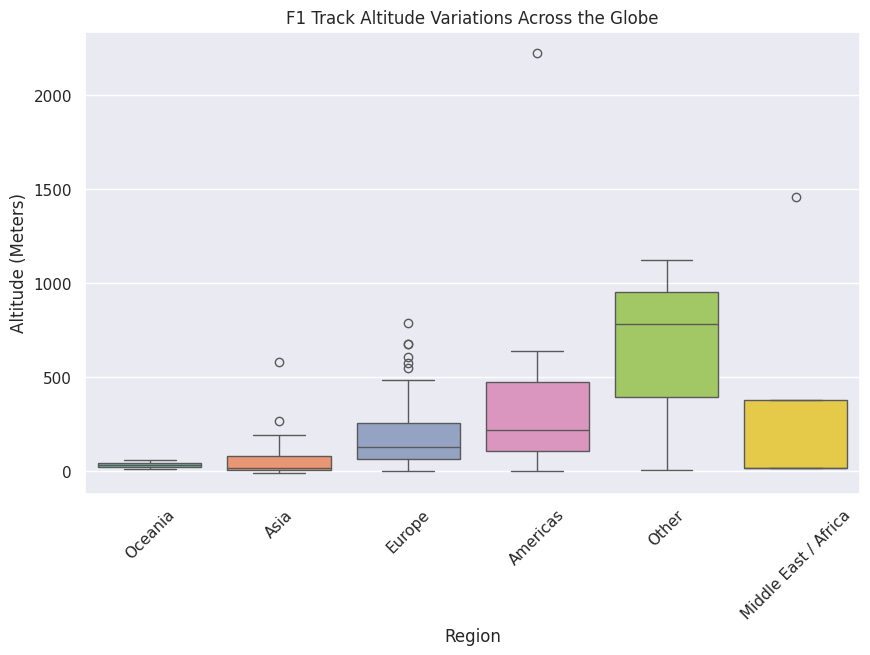

In [20]:
import plotly.express as px


print("--- 1. THE F1 GLOBAL CALENDAR MAP ---")
fig = px.scatter_geo(df,
                     lat='lat',
                     lon='lng',
                     hover_name='name',
                     hover_data=['country', 'alt'],
                     color='Region',
                     size=abs(df['alt']),
                     projection="natural earth",
                     title="Global Distribution of F1 Circuits (Sized by Altitude)")

fig.show()

print("\n--- 2. ALTITUDE DISTRIBUTION BY REGION ---")

# Here we figure out which region has the most extreme engine conditions?
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='alt', data=df, palette='Set2')
plt.title('F1 Track Altitude Variations Across the Globe')
plt.ylabel('Altitude (Meters)')
plt.xticks(rotation=45)
plt.show()

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("--- CLUSTERING F1 TRACKS BY GEOGRAPHY ---")
gps_data = df[['lat', 'lng']]

# Scaling the coordinates so Longitude doesn't overpower Latitude
scaler = StandardScaler()
gps_scaled = scaler.fit_transform(gps_data)

kmeans = KMeans(n_clusters=4, random_state=42)
df['Logistics_Hub'] = kmeans.fit_predict(gps_scaled)

print("successfully grouped all tracks into 4 logistical zones.")

# Visualizing the logistical groups on a map
fig_ai = px.scatter_geo(df,
                     lat='lat',
                     lon='lng',
                     hover_name='name',
                     color=df['Logistics_Hub'].astype(str),
                     projection="orthographic",
                     title="Generated F1 Logistics Hubs (K-Means Clustering)")

fig_ai.show()

--- CLUSTERING F1 TRACKS BY GEOGRAPHY ---
successfully grouped all tracks into 4 logistical zones.


# Machine Learning

--- 1. PREPARING OUR TRACK DATA ---
✅ Data is cleaned, scaled, and ready to go.

--- 2. CREATING OUR TRACK PROFILES ---
✅ We successfully separated the calendar into 4 unique Track Profiles.

--- 3. VISUALIZING OUR FINDINGS ---


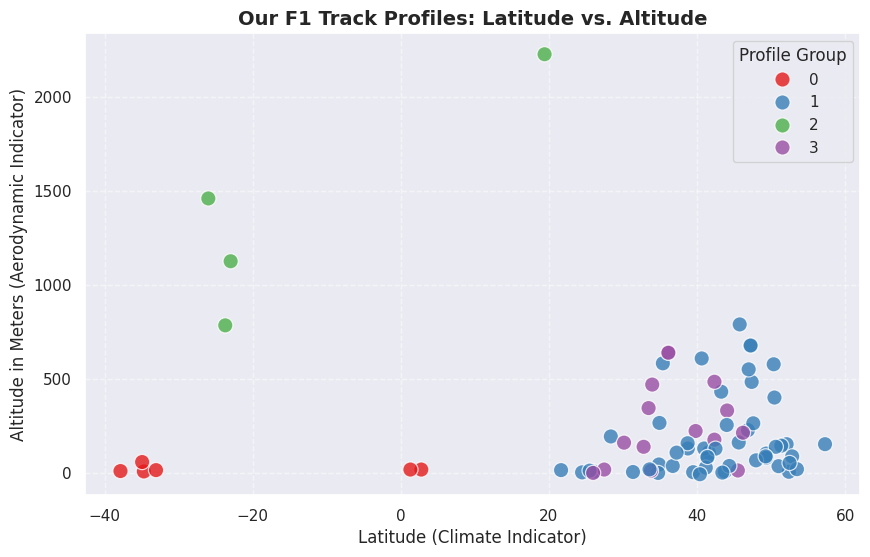

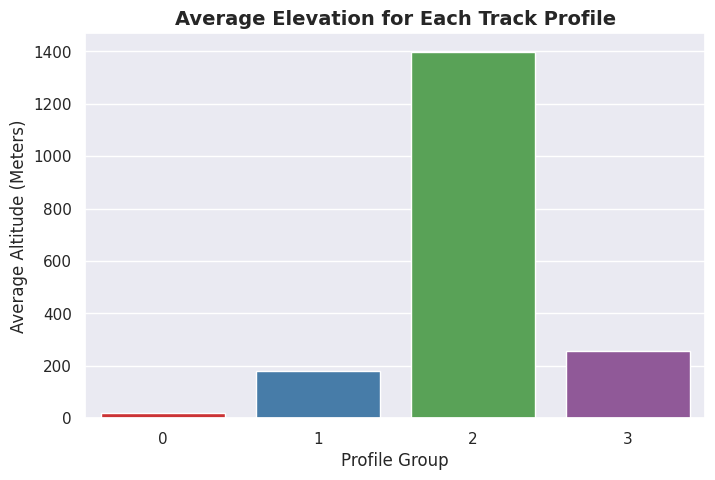


--- 4. REVIEWING THE GROUPS ---
🏎️ Sample tracks in Profile 0: ['Albert Park Grand Prix Circuit', 'Sepang International Circuit', 'Marina Bay Street Circuit', 'Autódromo Juan y Oscar Gálvez', 'Adelaide Street Circuit']


In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("--- 1. PREPARING OUR TRACK DATA ---")
# I want to see if we can naturally group our tracks into distinct "Profiles"
# based strictly on their physical geography, ignoring what country they are in.
# We will look at Altitude, Latitude, and Longitude.

features = ['alt', 'lat', 'lng']

# Let's drop any tracks that are missing this data so our math doesn't crash
df_ml = df[['name'] + features].dropna().copy()

# Altitude is measured in thousands, but coordinates are much smaller numbers.
# I need to scale everything to a level playing field so altitude doesn't overpower the math.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_ml[features])
print("✅ Data is cleaned, scaled, and ready to go.")


print("\n--- 2. CREATING OUR TRACK PROFILES ---")
# Let's group all the tracks into 4 distinct clusters to see what patterns emerge.
kmeans = KMeans(n_clusters=4, random_state=42)
df_ml['Track_Profile'] = kmeans.fit_predict(scaled_data)

print("✅ We successfully separated the calendar into 4 unique Track Profiles.")


print("\n--- 3. VISUALIZING OUR FINDINGS ---")
# Now I want to actually see what these groups look like.
# First, let's plot Latitude (how far North/South they are) against Altitude.

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='lat',
    y='alt',
    hue='Track_Profile',
    palette='Set1',
    data=df_ml,
    s=120,
    alpha=0.8
)
plt.title('Our F1 Track Profiles: Latitude vs. Altitude', fontsize=14, fontweight='bold')
plt.xlabel('Latitude (Climate Indicator)', fontsize=12)
plt.ylabel('Altitude in Meters (Aerodynamic Indicator)', fontsize=12)
plt.legend(title='Profile Group')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Second, I want to clearly see the altitude differences between the groups we just made.
# Let's calculate the average altitude for each profile and plot it.
profile_summary = df_ml.groupby('Track_Profile')['alt'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Track_Profile', y='alt', data=profile_summary, palette='Set1')
plt.title('Average Elevation for Each Track Profile', fontsize=14, fontweight='bold')
plt.xlabel('Profile Group', fontsize=12)
plt.ylabel('Average Altitude (Meters)', fontsize=12)
plt.show()

print("\n--- 4. REVIEWING THE GROUPS ---")
# Let's peek at a few tracks in 'Group 0' to see who got bundled together
group_0_tracks = df_ml[df_ml['Track_Profile'] == 0]['name'].head(5).tolist()
print(f"🏎️ Sample tracks in Profile 0: {group_0_tracks}")

# Thank You